In [1]:
## importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
from pathlib import Path

data_candidates = [
    "Titanic-Dataset.csv",
    "train.csv",
    "/kaggle/input/titanic/train.csv",
    "/kaggle/input/titanic-dataset/train.csv",
]

for data_path in data_candidates:
    if Path(data_path).exists():
        df = pd.read_csv(data_path)
        break
else:
    raise FileNotFoundError("Titanic dataset file not found in local folder or Kaggle input path.")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Cleaning
### Handling Missing values
1. Handling Missing values
2. Handling Duplicates
3. Check data type
4. Understand the dataset

In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
## Check Misssing Values
##these are the features with nan value
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')

Age 19.86532 % missing values
Cabin 77.10438 % missing values
Embarked 0.22447 % missing values


In [6]:
# statistics on numerical columns (Null cols)
df[features_with_na].select_dtypes(exclude='object').describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


## Imputing Null values


In [7]:
#Age
df.Age.fillna(df.Age.median(), inplace=True)

#TypeofContract
df.Embarked.fillna(df.Embarked.mode()[0], inplace=True)

#DurationOfPitch
df.Fare.fillna(df.Fare.median(), inplace=True)

#cabin drop



In [8]:
df.head()
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [9]:
df.drop('Cabin', axis=1, inplace=True, errors='ignore')

## Feature Engineering

### Feature Extraction

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [11]:
df.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True, errors='ignore')

In [12]:
## get all the numeric features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 6


In [13]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [14]:
##categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 2


In [15]:
## Discrete features
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))

Num of Discrete Features : 4


In [16]:
## coontinuous features
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Continuous Features : 2


In [17]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Train Test Split And Model Training

In [18]:
from sklearn.model_selection import train_test_split
X = df.drop(['Survived'], axis=1)
y = df['Survived']

In [19]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [20]:
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [21]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [22]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((712, 7), (179, 7))

In [23]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [24]:
# Create Column Transformer with 3 types of transformers
cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
         ("OneHotEncoder", oh_transformer, cat_features),
          ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [25]:
preprocessor

,transformers,"[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [26]:
## applying Trnsformation in training(fit_transform)
X_train=preprocessor.fit_transform(X_train)

In [27]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7
0,1.0,0.0,1.0,-1.614136,1.253641,-0.470722,-0.479342,-0.078684
1,1.0,0.0,1.0,-0.400551,-0.477284,-0.470722,-0.479342,-0.377145
2,1.0,0.0,1.0,0.813034,0.215086,-0.470722,-0.479342,-0.474867
3,1.0,0.0,1.0,0.813034,-0.246494,0.379923,-0.479342,-0.476230
4,0.0,0.0,1.0,0.813034,-1.785093,2.931860,2.048742,-0.025249
...,...,...,...,...,...,...,...,...
707,0.0,0.0,1.0,0.813034,-0.631144,-0.470722,-0.479342,-0.480162
708,1.0,0.0,1.0,-1.614136,-0.092634,-0.470722,-0.479342,-0.030545
709,1.0,0.0,1.0,0.813034,0.907456,1.230569,-0.479342,-0.355804
710,0.0,0.0,1.0,-1.614136,-1.169653,0.379923,2.048742,1.683201


In [28]:
## apply tansformation on test(transform)
X_test=preprocessor.transform(X_test)

In [29]:
X_test

array([[ 1.        ,  0.        ,  0.        , ...,  0.37992316,
         0.78470001, -0.33390078],
       [ 1.        ,  0.        ,  1.        , ..., -0.47072241,
        -0.47934164, -0.42528387],
       [ 1.        ,  0.        ,  1.        , ..., -0.47072241,
        -0.47934164, -0.47486697],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.37992316,
         5.8408666 , -0.02308312],
       [ 0.        ,  0.        ,  1.        , ..., -0.47072241,
        -0.47934164, -0.42528387],
       [ 0.        ,  0.        ,  1.        , ...,  0.37992316,
         0.78470001, -0.30589933]], shape=(179, 8))

## XgboostBoost Classifier Training
#### We can also combine multiple algorithms


In [30]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7
0,1.0,0.0,1.0,-1.614136,1.253641,-0.470722,-0.479342,-0.078684
1,1.0,0.0,1.0,-0.400551,-0.477284,-0.470722,-0.479342,-0.377145
2,1.0,0.0,1.0,0.813034,0.215086,-0.470722,-0.479342,-0.474867
3,1.0,0.0,1.0,0.813034,-0.246494,0.379923,-0.479342,-0.476230
4,0.0,0.0,1.0,0.813034,-1.785093,2.931860,2.048742,-0.025249
...,...,...,...,...,...,...,...,...
707,0.0,0.0,1.0,0.813034,-0.631144,-0.470722,-0.479342,-0.480162
708,1.0,0.0,1.0,-1.614136,-0.092634,-0.470722,-0.479342,-0.030545
709,1.0,0.0,1.0,0.813034,0.907456,1.230569,-0.479342,-0.355804
710,0.0,0.0,1.0,-1.614136,-1.169653,0.379923,2.048742,1.683201


In [31]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [33]:
models={
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Adaboost":AdaBoostClassifier(),
    "Xgboost":XGBClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.8006
- F1 score: 0.7985
- Precision: 0.7582
- Recall: 0.6903
- Roc Auc Score: 0.7787
----------------------------------
Model performance for Test set
- Accuracy: 0.8101
- F1 score: 0.8092
- Precision: 0.7857
- Recall: 0.7432
- Roc Auc Score: 0.8002


Decision Tree
Model performance for Training set
- Accuracy: 0.9789
- F1 score: 0.9788
- Precision: 0.9961
- Recall: 0.9478
- Roc Auc Score: 0.9728
----------------------------------
Model performance for Test set
- Accuracy: 0.7933
- F1 score: 0.7931
- Precision: 0.7534
- Recall: 0.7432
- Roc Auc Score: 0.7859


Random Forest
Model performance for Training set
- Accuracy: 0.9789
- F1 score: 0.9789
- Precision: 0.9884
- Recall: 0.9552
- Roc Auc Score: 0.9742
----------------------------------
Model performance for Test set
- Accuracy: 0.8156
- F1 score: 0.8155
- Precision: 0.7808
- Recall: 0.7703
- Roc Auc Score: 0.8089


Gradient Boost
Model performance for Training se

In [34]:
## Hyperparameter Training
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "sqrt", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}
xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8, 12, 20, 30],
                  "n_estimators": [100, 200, 300],
                  "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

In [35]:
rf_params

{'max_depth': [5, 8, 15, None, 10],
 'max_features': [5, 7, 'sqrt', 8],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200, 500, 1000]}

In [36]:
xgboost_params

{'learning_rate': [0.1, 0.01],
 'max_depth': [5, 8, 12, 20, 30],
 'n_estimators': [100, 200, 300],
 'colsample_bytree': [0.5, 0.8, 1, 0.3, 0.4]}

In [37]:
# Models list for Hyperparameter tuning
randomcv_models = [
                   ("RF", RandomForestClassifier(), rf_params),
    ("Xgboost", XGBClassifier(), xgboost_params)
                   
                   ]

In [38]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'sqrt', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]}),
 ('Xgboost',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...),
  {'lea

In [39]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END max_depth=5, max_features=8, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END max_depth=5, max_features=8, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END max_depth=5, max_features=8, min_samples_split=20, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, max_features=8, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=8, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, max_features=8, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=8, max_features=5, min_samples_split=15, n_estimators=200; total time=   0.2s
[CV] END max_depth=8, max_features=5, min_samples_split=15, n_estimators=200; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=20, n_estimators=200; total time=   0.1s
[CV] END max_depth=5, max_features=5, min_samples_split=20, n

In [40]:
models={
    
    "Random Forest":RandomForestClassifier(n_estimators=200,min_samples_split=8,
                                          max_features=8,max_depth=5),
    "Xgboost":XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.01,
                           colsample_bytree=0.5)
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Random Forest
Model performance for Training set
- Accuracy: 0.8652
- F1 score: 0.8609
- Precision: 0.9135
- Recall: 0.7090
- Roc Auc Score: 0.8342
----------------------------------
Model performance for Test set
- Accuracy: 0.7877
- F1 score: 0.7824
- Precision: 0.8103
- Recall: 0.6351
- Roc Auc Score: 0.7652


Xgboost
Model performance for Training set
- Accuracy: 0.8610
- F1 score: 0.8557
- Precision: 0.9246
- Recall: 0.6866
- Roc Auc Score: 0.8264
----------------------------------
Model performance for Test set
- Accuracy: 0.8156
- F1 score: 0.8121
- Precision: 0.8361
- Recall: 0.6892
- Roc Auc Score: 0.7970




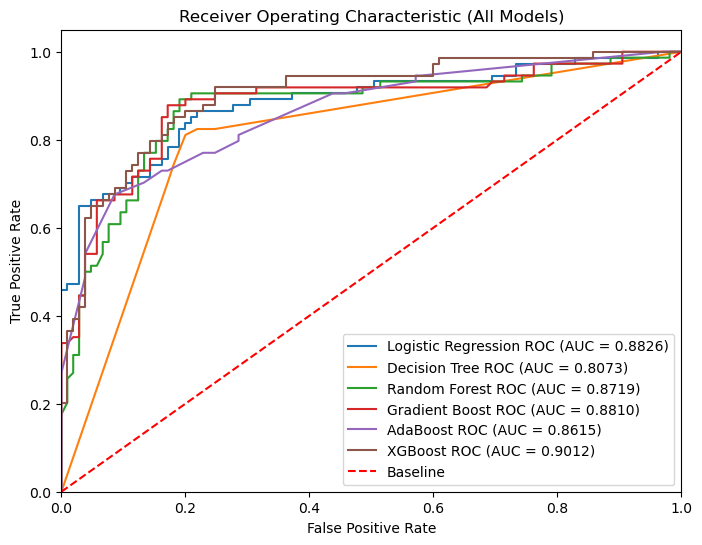

In [41]:
## Plot ROC AUC Curve for all models
from sklearn.metrics import roc_auc_score, roc_curve

roc_models = [
    {
        'label': 'Logistic Regression',
        'model': LogisticRegression(max_iter=1000)
    },
    {
        'label': 'Decision Tree',
        'model': DecisionTreeClassifier(random_state=42)
    },
    {
        'label': 'Random Forest',
        'model': RandomForestClassifier(n_estimators=200,min_samples_split=8,
                                          max_features=8,max_depth=5)
    },
    {
        'label': 'Gradient Boost',
        'model': GradientBoostingClassifier(random_state=42)
    },
    {
        'label': 'AdaBoost',
        'model': AdaBoostClassifier(random_state=42)
    },
    {
        'label': 'XGBoost',
        'model': XGBClassifier(
            n_estimators=200,
            max_depth=20,
            learning_rate=0.01,
            colsample_bytree=0.5,
            eval_metric='logloss',
            random_state=42
        )
    },
]

plt.figure(figsize=(8, 6))

for algo in roc_models:
    model = algo['model']
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{algo['label']} ROC (AUC = {auc_score:.4f})")

# Baseline (random classifier)
plt.plot([0, 1], [0, 1], 'r--', label='Baseline')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (All Models)')
plt.legend(loc='lower right')
plt.savefig('auc_all_models.png')
plt.show()

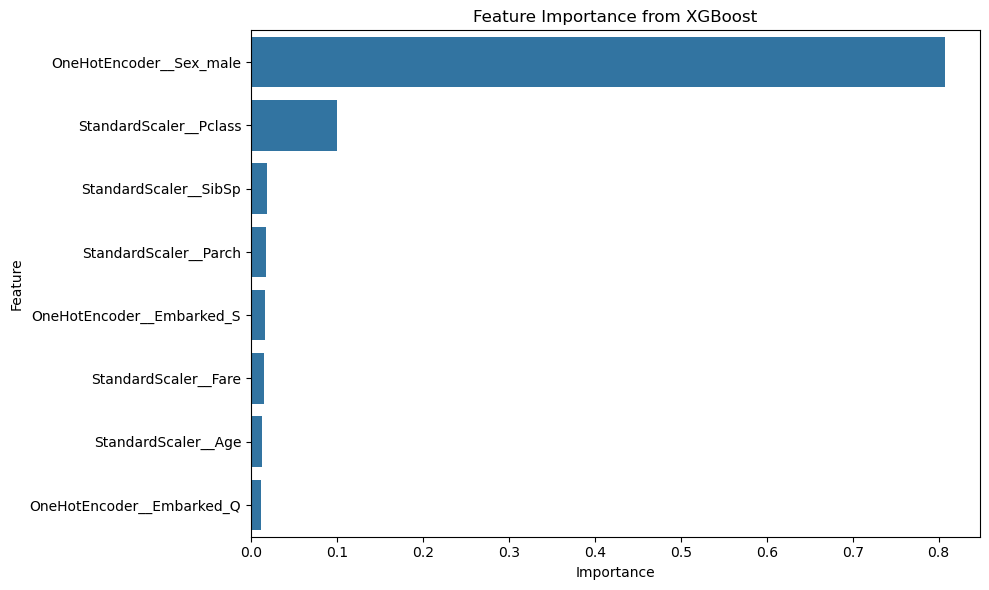

In [42]:
#evaluate feature importance for xgboost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=20,
    learning_rate=0.01,
    colsample_bytree=0.5,
    eval_metric='logloss',
    random_state=42
)               
xgb_model.fit(X_train, y_train)
feature_importance = xgb_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)
plt.figure(figsize=(10, 6))             
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from XGBoost')
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png')
plt.show()
